Create a solution that predicts the price of car based on model year,KM and color

In [1]:
# Import all libraries need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

import pickle

In [2]:
# Load the csv into dataframe
df = pd.read_csv('teslay.csv')

In [3]:
# Perform basic checks
df.head()

,year,km,color,price
0,2025,69000.0,White,2095000
1,2024,28500.0,Black,2280000
2,2024,50000.0,White,2090000
3,2024,42000.0,White,2180000
4,2024,15000.0,White,2300000


In [4]:
df.tail()

,year,km,color,price
250,2025,24000.0,Black,2390000
251,2024,29000.0,White,2185000
252,2025,19800.0,White,2305000
253,2024,16000.0,White,2250000
254,2024,34000.0,White,2310000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    255 non-null    int64  
 1   km      255 non-null    float64
 2   color   255 non-null    object 
 3   price   255 non-null    int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 8.1+ KB


In [6]:
df.describe()


,year,km,price
count,255.000000,255.000000,2.550000e+02
mean,2024.207843,30384.172549,2.247061e+06
std,0.406562,15563.810709,1.517529e+05
min,2024.000000,6001.000000,1.825000e+06
25%,2024.000000,19880.000000,2.160000e+06
50%,2024.000000,29000.000000,2.239750e+06
75%,2024.000000,39000.000000,2.322500e+06
max,2025.000000,110000.000000,3.100000e+06


In [7]:
df.describe(include='O')

,color
count,255
unique,9
top,White
freq,180


* Total records: 255 cars
* Features available:
* year – manufacturing year
* km – kilometers driven
* color – categorical feature
* price – target variable

There are no missing values, so data cleaning is minimal.

# Exploratory Data Analysis

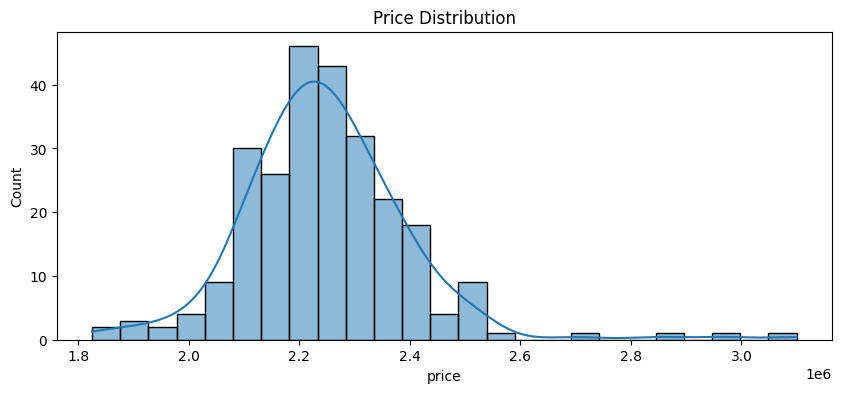

In [8]:
# Univariate Analysis
plt.figure(figsize=(10,4))
sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.show()

* Average price: ₹2,247,061
* Minimum price: ₹1,825,000
* Maximum price: ₹3,100,000

Most car prices lie between:

₹2.16M – ₹2.32M

This means the dataset has moderate variance, which is good for regression.

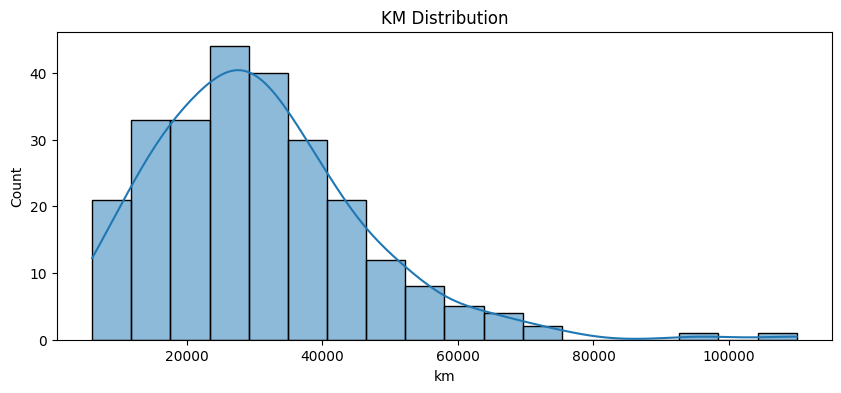

In [9]:
plt.figure(figsize=(10,4))
sns.histplot(df['km'], kde=True)
plt.title("KM Distribution")
plt.show()

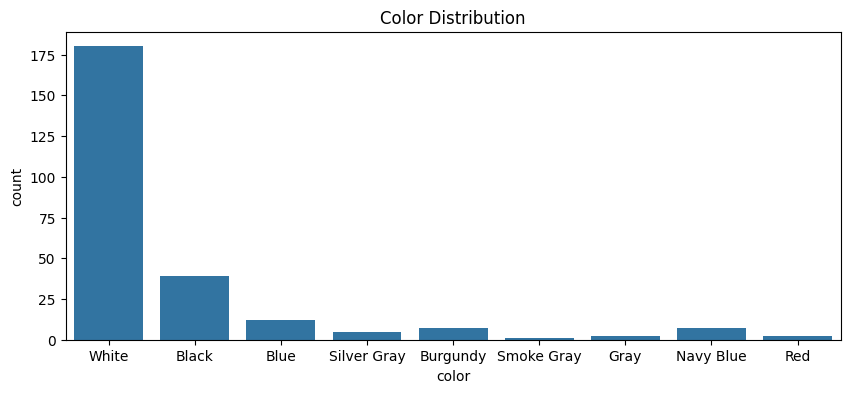

In [10]:
plt.figure(figsize=(10,4))
sns.countplot(x='color', data=df)
plt.title("Color Distribution")
plt.show()

Insight:

White dominates the dataset (~70%)
Other colors are rare categories

Implication for ML:

Color may have low predictive power
But it still needs one-hot encoding

## Get correlation

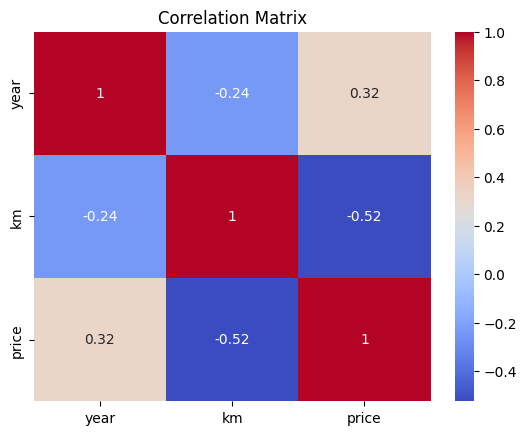

In [11]:
numeric_df = df[['year','km','price']]

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

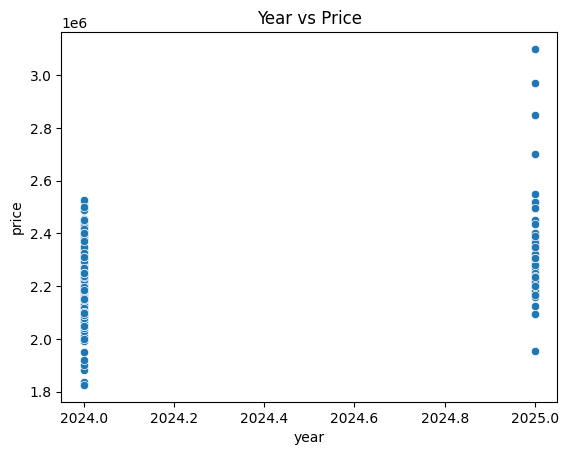

In [12]:
sns.scatterplot(x='year', y='price', data=df)
plt.title("Year vs Price")
plt.show()

Values in the dataset:

2024
2025

Average year ≈ 2024.2

Insight:

Cars from 2025 tend to have slightly higher prices.
Correlation with price ≈ +0.32 (moderate positive).

Meaning:
 Newer cars are more expensive, which is expected.

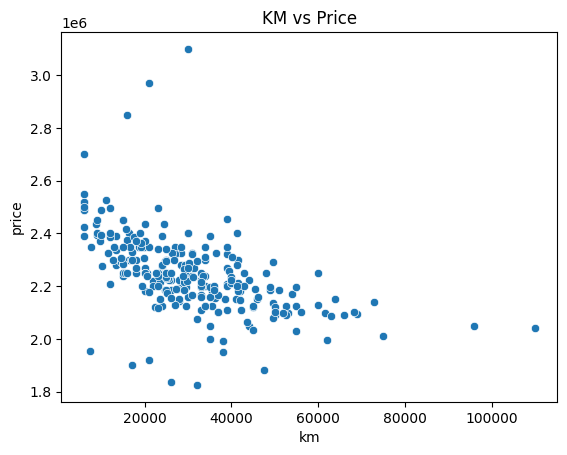

In [13]:
sns.scatterplot(x='km', y='price', data=df)
plt.title("KM vs Price")
plt.show()

* Average km driven:

30,384 km

Range:

Minimum: 6,001 km
Maximum: 110,000 km

Correlation with price:

-0.52

This is the strongest relationship in the dataset.

Meaning:

 As km increases, price decreases.

This feature will likely be the most important predictor in the linear regression model.

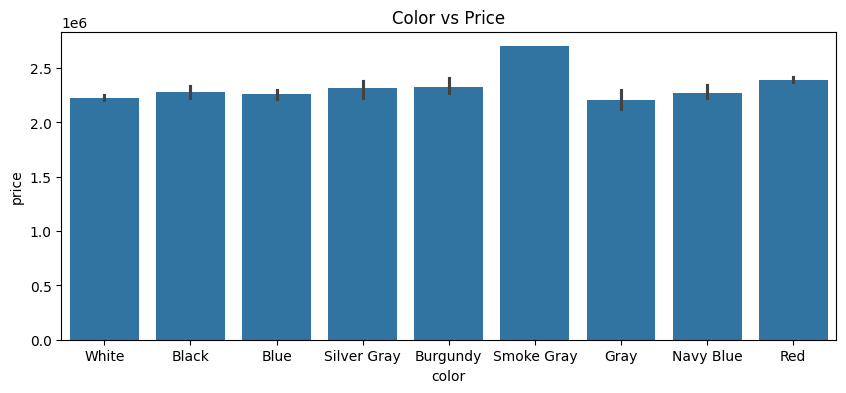

In [14]:
plt.figure(figsize=(10,4))
sns.barplot(x='color', y='price', data=df)
plt.title("Color vs Price") 
plt.show()

Insights
* Color does not significantly affect price.
* Dark colors (Black / Navy Blue) appear slightly more expensive.
* The bar plot between color and price shows the average price of vehicles for each color category. The differences between colors are relatively small, indicating that color has limited influence on price compared to other variables such as kilometers driven or manufacturing year.

# Data Preprocessing

In [15]:
df = pd.get_dummies(df, columns=['color'], drop_first=True)

df.head()

,year,km,price,color_Blue,color_Burgundy,color_Gray,color_Navy Blue,color_Red,color_Silver Gray,color_Smoke Gray,color_White
0,2025,69000.0,2095000,False,False,False,False,False,False,False,True
1,2024,28500.0,2280000,False,False,False,False,False,False,False,False
2,2024,50000.0,2090000,False,False,False,False,False,False,False,True
3,2024,42000.0,2180000,False,False,False,False,False,False,False,True
4,2024,15000.0,2300000,False,False,False,False,False,False,False,True


In [16]:
# Model Building

In [17]:
X = df.drop('price', axis=1)
y = df['price']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
y_pred = model.predict(X_test)

In [21]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.4935036213292605


49% of price differences are explained by
year
km
color
51% is due to other unknown factors like
car condition
variant
battery health
location
ownership history

In [22]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 10001345473.965137


In [23]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 100006.72714355339


In [24]:
mae = mean_absolute_error(y_test, y_pred)

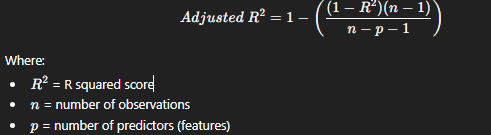

In [25]:
n = X_test.shape[0]   # number of observations
p = X_test.shape[1]   # number of predictors

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Adjusted R2:", adj_r2)

Adjusted R2: 0.36687952666157564


In [26]:
# Model Coefficient

In [27]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

             Feature   Coefficient
0               year  85795.963392
1                 km     -4.435036
2         color_Blue  42790.326565
3     color_Burgundy  53006.109950
4         color_Gray  59793.442315
5    color_Navy Blue  58124.993937
6          color_Red  90102.646542
7  color_Silver Gray  76620.205047
8   color_Smoke Gray      0.000000
9        color_White -27019.684256


In [28]:
with open("car_price_model.pkl", "wb") as file:
    pickle.dump(model, file)

In [29]:
X_train.columns

Index(['year', 'km', 'color_Blue', 'color_Burgundy', 'color_Gray',
       'color_Navy Blue', 'color_Red', 'color_Silver Gray', 'color_Smoke Gray',
       'color_White'],
      dtype='object')

In [30]:
data = {
'year':[2025],
'km':[15000],
'color_Blue':[0],
'color_Burgundy':[0],
'color_Gray':[0],
'color_Navy Blue':[0],
'color_Red':[0],
'color_Silver Gray':[0],
'color_Smoke Gray':[0],
'color_White':[1]
}

input_data = pd.DataFrame(data)

In [31]:
prediction = model.predict(input_data)

print("Predicted Price:", prediction[0])

Predicted Price: 2369378.4492385387


## Evalution Metrics

R² Score (R-squared)
What it tells

How well the model explains the relationship between input features and price.

In simple words:

How much of the price variation the model is able to explain.

0  → model explains nothing
1  → perfect prediction

Mean Squared Error (MSE)
What it tells

The average squared difference between predicted price and actual price.
(actual price − predicted price)²

Why square the error?

Because:

big mistakes should be punished more
negative errors become positive

MSE tells how badly the model is making mistakes overall.

In [32]:
RMSE (Root Mean Squared Error)

On average the model makes this much price mistake.

if RMSE = 120000
it means On average the model prediction is ₹1.2 lakh away from the actual price.

SyntaxError: invalid character '₹' (U+20B9) (3024364495.py, line 6)

MAE (Mean Absolute Error)
What it measures

The average absolute difference between predicted price and actual price.

MAE = average(|Actual − Predicted|)

MAE tells us how far our predictions are from the real price on average.

Why MAE is useful
Easy to understand
Not heavily affected by outliers

Adjusted R²

It always increases when we add more features, even if they are useless.

Suppose you add useless features:

car color
owner's favorite food
random number

R² might increase slightly even though they are not useful.

It penalizes unnecessary features.

Meaning:

 It only increases if the new feature actually improves the model.

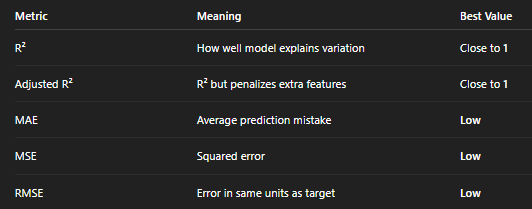